In [5]:
# Cell 1 — imports
from pathlib import Path
import pandas as pd
import scanpy as sc

In [6]:
# Cell 2 — settings
stage = "st22"
input_h5ad = Path("adata_xeno_with_symbols.h5ad")
input_liana_csv = Path("st22_liana_res_phenograph.csv")
output_dir = Path("st22_gene_lr_extract")
output_dir.mkdir(exist_ok=True)

genes_of_interest = {
    "DLL1", "JAG1", "NOTCH1", "NOTCH2", "MDK"
}

In [7]:
# Cell 3 — load stage 22 data
adata = sc.read_h5ad(input_h5ad)
adata_st22 = adata[adata.obs["Stages"] == stage].copy()
adata_st22.var_names = adata_st22.var["ORTHOLOG_HUMAN_SYMBOL"].astype(str)
adata_st22.var_names_make_unique()

print(adata_st22)
print(adata_st22.obs["Phenograph"].value_counts().sort_index())

AnnData object with n_obs × n_vars = 5217 × 41560
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample', 'in_meta'
    var: 'raw_name', 'xeno_symbol', 'ORTHOLOG_HUMAN_SYMBOL'
Phenograph
Bc1          671
Bc2          290
Bc3         2121
Bc4          102
Eep1          12
Eep2           8
Eep3         217
Eep4          20
Gc          1159
Ic           239
Mcc2          14
Mcc3         363
Mcc/CCPs       1
Name: count, dtype: int64


In [8]:
# Cell 4 — load LIANA results
input_liana_csv = Path("st22_liana_res_phenograph.csv")

if input_liana_csv.exists():
    res = pd.read_csv(input_liana_csv)
else:
    res = adata_st22.uns["lianares"].copy()
    res.to_csv(output_dir / "st22_lianares_from_adata.csv", index=False)

print(res.shape)
print(res.columns)

(6543, 13)
Index(['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means',
       'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc',
       'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank'],
      dtype='object')


In [9]:
# Cell 5 — clean column names
for col in ["ligand_complex", "receptor_complex", "source", "target"]:
    if col in res.columns:
        res[col] = res[col].astype(str).str.strip()


In [10]:
# Cell 6 — extract all interactions involving the genes of interest
# genes_of_interest example:
# genes_of_interest = {"DLL1", "JAG1", "JAG2", "NOTCH1", "NOTCH2", "MDK"}

# make sure the relevant columns are strings without extra spaces
for col in ["ligand_complex", "receptor_complex", "source", "target"]:
    res[col] = res[col].astype(str).str.strip()

# keep rows where ANY selected gene appears as ligand or receptor
mask = (
    res["ligand_complex"].isin(genes_of_interest) |
    res["receptor_complex"].isin(genes_of_interest)
)

hits = res.loc[mask].copy()

# create a readable LR-pair label
hits["lr_pair"] = hits["ligand_complex"] + " -> " + hits["receptor_complex"]

# optional: show which selected gene triggered the match
hits["matched_gene"] = hits.apply(
    lambda row: ",".join(
        sorted(
            set([row["ligand_complex"], row["receptor_complex"]]) & set(genes_of_interest)
        )
    ),
    axis=1
)

# sort so the strongest-ranked interactions are first
hits = hits.sort_values(
    ["magnitude_rank", "specificity_rank", "lrscore"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("Total hits:", len(hits))
print("Unique LR pairs:", hits["lr_pair"].nunique())

# display ALL selected interactions as a table in the notebook
display(
    hits[[
        "matched_gene",
        "source",
        "target",
        "ligand_complex",
        "receptor_complex",
        "lr_pair",
        "lrscore",
        "specificity_rank",
        "magnitude_rank",
        "lr_means"
    ]]
)


Total hits: 1072
Unique LR pairs: 24


,matched_gene,source,target,ligand_complex,receptor_complex,lr_pair,lrscore,specificity_rank,magnitude_rank,lr_means
0,MDK,Bc3,Eep1,MDK,NCL,MDK -> NCL,0.966337,0.009079,2.102056e-07,0.746357
1,MDK,Bc3,Bc1,MDK,NCL,MDK -> NCL,0.965090,0.009079,1.029378e-05,0.698018
2,MDK,Bc4,Eep1,MDK,NCL,MDK -> NCL,0.959294,0.009079,1.344357e-05,0.720236
3,MDK,Bc2,Eep1,MDK,NCL,MDK -> NCL,0.958480,0.009079,1.701278e-05,0.718052
4,MDK,Bc4,Bc1,MDK,NCL,MDK -> NCL,0.957798,0.009079,2.540897e-05,0.671898
...,...,...,...,...,...,...,...,...,...,...
1067,NOTCH1,Eep3,Eep3,PSEN1,NOTCH1,PSEN1 -> NOTCH1,0.300279,1.000000,1.000000e+00,0.007429
1068,NOTCH1,Bc3,Bc2,ADAM17,NOTCH1,ADAM17 -> NOTCH1,0.299569,1.000000,1.000000e+00,0.007154
1069,NOTCH1,Eep3,Gc,MFAP2,NOTCH1,MFAP2 -> NOTCH1,0.298878,1.000000,1.000000e+00,0.007609
1070,"JAG1,NOTCH1",Bc2,Bc3,JAG1,NOTCH1,JAG1 -> NOTCH1,0.297843,1.000000,1.000000e+00,0.008269


In [11]:
# Cell 7 — keep only unique LR pairs, no ranking preference

before_rows = len(hits)
before_unique_pairs = hits["lr_pair"].nunique()

print(f"Before deduplication: {before_rows} rows")
print(f"Before deduplication: {before_unique_pairs} unique LR pairs")

hits_unique = (
    hits.drop_duplicates(subset=["lr_pair"], keep="first")
       .reset_index(drop=True)
)

after_rows = len(hits_unique)
after_unique_pairs = hits_unique["lr_pair"].nunique()

print(f"After deduplication: {after_rows} rows")
print(f"After deduplication: {after_unique_pairs} unique LR pairs")
print(f"Duplicates removed: {before_rows - after_rows}")

display(
    hits_unique[[
        "matched_gene",
        "source",
        "target",
        "ligand_complex",
        "receptor_complex",
        "lr_pair",
        "lrscore",
        "specificity_rank",
        "magnitude_rank",
        "lr_means"
    ]]
)

Before deduplication: 1072 rows
Before deduplication: 24 unique LR pairs
After deduplication: 24 rows
After deduplication: 24 unique LR pairs
Duplicates removed: 1048


,matched_gene,source,target,ligand_complex,receptor_complex,lr_pair,lrscore,specificity_rank,magnitude_rank,lr_means
0,MDK,Bc3,Eep1,MDK,NCL,MDK -> NCL,0.966337,0.009079,2.102056e-07,0.746357
1,NOTCH1,Bc1,Bc1,YBX1,NOTCH1,YBX1 -> NOTCH1,0.889630,0.009079,7.598202e-03,0.264178
2,DLL1,Bc2,Gc,DLL1,NOTCH3,DLL1 -> NOTCH3,0.171397,1.000000,2.879322e-02,0.003338
3,MDK,Bc3,Mcc2,MDK,SDC2,MDK -> SDC2,0.858083,0.008787,3.242353e-02,0.109671
4,MDK,Bc3,Ic,MDK,TSPAN1,MDK -> TSPAN1,0.837419,0.001233,3.784652e-02,0.101564
5,MDK,Bc3,Bc4,MDK,ITGA6_ITGB1,MDK -> ITGA6_ITGB1,0.831953,0.002872,3.991722e-02,0.099930
6,MDK,Bc3,Bc3,MDK,SDC1,MDK -> SDC1,0.804087,0.001838,4.403203e-02,0.093733
7,MDK,Bc3,Bc1,MDK,SDC4,MDK -> SDC4,0.801205,0.000205,4.458282e-02,0.093247
8,MDK,Bc3,Gc,MDK,PTPRZ1,MDK -> PTPRZ1,0.772714,0.002418,5.007361e-02,0.089459
9,JAG1,Bc2,Gc,JAG1,NOTCH3,JAG1 -> NOTCH3,0.182256,1.000000,5.332599e-02,0.003587


In [12]:
# Cell 8 — ligand-receptor interactions + DGIdb annotation

# --- 1) Ligand-receptor interactions ---
for col in ["ligand_complex", "receptor_complex", "source", "target"]:
    res[col] = res[col].astype(str).str.strip()

mask_lr = (
    res["ligand_complex"].isin(genes_of_interest) |
    res["receptor_complex"].isin(genes_of_interest)
)

hits_lr = res.loc[mask_lr].copy()
hits_lr["lr_pair"] = hits_lr["ligand_complex"] + " -> " + hits_lr["receptor_complex"]
hits_lr["matched_side"] = hits_lr.apply(
    lambda r: (
        "ligand" if r["ligand_complex"] in genes_of_interest else ""
    ) + (
        "|receptor" if r["receptor_complex"] in genes_of_interest else ""
    ).strip("|"),
    axis=1
)

hits_lr = hits_lr.sort_values(
    ["magnitude_rank", "specificity_rank", "lrscore"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("Ligand-receptor hits:", len(hits_lr))
display(
    hits_lr[[
        "matched_side", "source", "target",
        "ligand_complex", "receptor_complex",
        "lr_pair", "lrscore", "specificity_rank", "magnitude_rank"
    ]]
)

# --- 2) DGIdb interactions ---
dg = pd.read_csv("dgidb_interactions.tsv", sep="\t", low_memory=False)

for col in ["gene_name", "drug_name", "interaction_type", "interaction_source_db_name"]:
    if col in dg.columns:
        dg[col] = dg[col].astype(str).str.strip()

mask_dgidb = dg["gene_name"].isin(genes_of_interest)
hits_dgidb = dg.loc[mask_dgidb].copy()

# optional: rank by interaction score if present
if "interaction_score" in hits_dgidb.columns:
    hits_dgidb = hits_dgidb.sort_values("interaction_score", ascending=False)

print("DGIdb hits:", len(hits_dgidb))
display(
    hits_dgidb[[
        "gene_name", "drug_name", "interaction_type",
        "interaction_score", "approved", "immunotherapy", "anti_neoplastic",
        "interaction_source_db_name"
    ]]
)

Ligand-receptor hits: 1072


,matched_side,source,target,ligand_complex,receptor_complex,lr_pair,lrscore,specificity_rank,magnitude_rank
0,ligand,Bc3,Eep1,MDK,NCL,MDK -> NCL,0.966337,0.009079,2.102056e-07
1,ligand,Bc3,Bc1,MDK,NCL,MDK -> NCL,0.965090,0.009079,1.029378e-05
2,ligand,Bc4,Eep1,MDK,NCL,MDK -> NCL,0.959294,0.009079,1.344357e-05
3,ligand,Bc2,Eep1,MDK,NCL,MDK -> NCL,0.958480,0.009079,1.701278e-05
4,ligand,Bc4,Bc1,MDK,NCL,MDK -> NCL,0.957798,0.009079,2.540897e-05
...,...,...,...,...,...,...,...,...,...
1067,receptor,Eep3,Eep3,PSEN1,NOTCH1,PSEN1 -> NOTCH1,0.300279,1.000000,1.000000e+00
1068,receptor,Bc3,Bc2,ADAM17,NOTCH1,ADAM17 -> NOTCH1,0.299569,1.000000,1.000000e+00
1069,receptor,Eep3,Gc,MFAP2,NOTCH1,MFAP2 -> NOTCH1,0.298878,1.000000,1.000000e+00
1070,ligandreceptor,Bc2,Bc3,JAG1,NOTCH1,JAG1 -> NOTCH1,0.297843,1.000000,1.000000e+00


DGIdb hits: 28


,gene_name,drug_name,interaction_type,interaction_score,approved,immunotherapy,anti_neoplastic,interaction_source_db_name
88048,NOTCH1,BRONTICTUZUMAB,nan,19.690377,False,False,True,CGI
8722,NOTCH1,BRONTICTUZUMAB,nan,19.690377,False,False,True,TTD
29341,NOTCH1,BRONTICTUZUMAB,inhibitor,19.690377,False,False,True,ChEMBL
51594,NOTCH2,TAREXTUMAB,nan,15.002192,False,False,True,TdgClinicalTrial
50334,NOTCH2,TAREXTUMAB,inhibitor,15.002192,False,False,True,ChEMBL
76323,NOTCH2,TAREXTUMAB,nan,15.002192,False,False,True,TTD
76263,NOTCH2,TAREXTUMAB,nan,15.002192,False,False,True,CGI
94089,JAG1,MARALIXIBAT,nan,8.751279,True,False,False,PharmGKB
69554,NOTCH1,RO4929097,nan,3.938075,False,False,True,CGI
55785,NOTCH1,RO4929097,other/unknown,3.938075,False,False,True,MyCancerGenome


In [14]:
# Cell 9 — LR pairs + approved DGIdb drugs

for col in ["ligand_complex", "receptor_complex", "source", "target"]:
    res[col] = res[col].astype(str).str.strip()

# 1) LR hits for the 6 genes
mask_lr = (
    res["ligand_complex"].isin(genes_of_interest) |
    res["receptor_complex"].isin(genes_of_interest)
)

hits_lr = res.loc[mask_lr].copy()
hits_lr["lr_pair"] = hits_lr["ligand_complex"] + " -> " + hits_lr["receptor_complex"]

hits_lr = hits_lr.sort_values(
    ["magnitude_rank", "specificity_rank", "lrscore"],
    ascending=[True, True, False]
).reset_index(drop=True)

# 2) Keep only the 24 unique LR pairs
unique_lr = hits_lr[["ligand_complex", "receptor_complex", "lr_pair"]].drop_duplicates().copy()

# 3) Build gene-to-LR-pair lookup
lr_long = pd.concat([
    unique_lr[["lr_pair", "ligand_complex"]].rename(columns={"ligand_complex": "gene_name"}),
    unique_lr[["lr_pair", "receptor_complex"]].rename(columns={"receptor_complex": "gene_name"})
], ignore_index=True).drop_duplicates()

# 4) Load DGIdb
dg = pd.read_csv("dgidb_interactions.tsv", sep="\t", low_memory=False)

for col in ["gene_name", "drug_name", "interaction_type", "interaction_source_db_name"]:
    if col in dg.columns:
        dg[col] = dg[col].astype(str).str.strip()

# 5) Filter to genes in the 24 LR pairs
hits_dgidb = dg[dg["gene_name"].isin(lr_long["gene_name"])].copy()

# 6) Keep only approved drugs
if "approved" in hits_dgidb.columns:
    hits_dgidb = hits_dgidb[hits_dgidb["approved"] == True].copy()

# 7) Merge drugs back to LR pairs
drug_links = hits_dgidb.merge(lr_long, on="gene_name", how="left")

# 8) Display final table
drug_links = drug_links.sort_values(
    ["lr_pair", "gene_name", "drug_name"]
).reset_index(drop=True)

print("Unique LR pairs:", unique_lr["lr_pair"].nunique())
print("Approved DGIdb drug links:", len(drug_links))

display(
    drug_links[[
        "lr_pair",
        "gene_name",
        "drug_name",
        "interaction_type",
        "interaction_source_db_name",
        "approved"
    ]].drop_duplicates()
)

Unique LR pairs: 24
Approved DGIdb drug links: 93


,lr_pair,gene_name,drug_name,interaction_type,interaction_source_db_name,approved
0,ADAM10 -> NOTCH1,ADAM10,BUMETANIDE,agonist,GuideToPharmacology,True
1,ADAM10 -> NOTCH1,ADAM10,FUROSEMIDE,agonist,GuideToPharmacology,True
2,ADAM10 -> NOTCH1,ADAM10,LODOXAMIDE TROMETHAMINE,agonist,GuideToPharmacology,True
3,ADAM10 -> NOTCH1,NOTCH1,HYDROCORTISONE BUTYRATE,nan,NCI,True
4,ADAM10 -> NOTCH1,NOTCH1,NIROGACESTAT,nan,CIViC,True
...,...,...,...,...,...,...
88,YBX1 -> NOTCH1,NOTCH1,HYDROCORTISONE BUTYRATE,nan,NCI,True
89,YBX1 -> NOTCH1,NOTCH1,NIROGACESTAT,nan,CIViC,True
90,YBX1 -> NOTCH1,NOTCH1,NIROGACESTAT,nan,CGI,True
91,YBX1 -> NOTCH1,NOTCH1,NIROGACESTAT,other/unknown,MyCancerGenome,True


In [9]:
# Display genes_of_interest
print(genes_of_interest)
print(unique_lr)

# If it's a list or set and you want a nicer table:
import pandas as pd
display(pd.DataFrame({"gene": sorted(list(genes_of_interest))}))

{'DLL1', 'JAG1', 'NOTCH2', 'MDK', 'NOTCH1'}
    ligand_complex receptor_complex             lr_pair
0              MDK              NCL          MDK -> NCL
110           YBX1           NOTCH1      YBX1 -> NOTCH1
173           DLL1           NOTCH3      DLL1 -> NOTCH3
182            MDK             SDC2         MDK -> SDC2
191            MDK           TSPAN1       MDK -> TSPAN1
196            MDK      ITGA6_ITGB1  MDK -> ITGA6_ITGB1
203            MDK             SDC1         MDK -> SDC1
205            MDK             SDC4         MDK -> SDC4
216            MDK           PTPRZ1       MDK -> PTPRZ1
220           JAG1           NOTCH3      JAG1 -> NOTCH3
234            MDK             LRP1         MDK -> LRP1
301         ADAM10           NOTCH2    ADAM10 -> NOTCH2
317            MDK      ITGA4_ITGB1  MDK -> ITGA4_ITGB1
323            MDK           NOTCH2       MDK -> NOTCH2
367           DLL1           NOTCH2      DLL1 -> NOTCH2
374         ADAM10           NOTCH1    ADAM10 -> NOTCH1
419 

,gene
0,DLL1
1,JAG1
2,MDK
3,NOTCH1
4,NOTCH2


In [15]:
# Cell 10 — Save DGIdb LR-drug results as CSV

output_file = "lr_pairs_dgidb_approved_drugs.csv"

drug_links[[
    "lr_pair",
    "gene_name",
    "drug_name",
    "interaction_type",
    "interaction_source_db_name",
    "approved"
]].drop_duplicates().to_csv(output_file, index=False)

print(f"Saved file: {output_file}")

Saved file: lr_pairs_dgidb_approved_drugs.csv


In [16]:
# ============================================================
# Group approved DGIdb drug links for thesis reporting
# ============================================================

# Keep only relevant columns and remove duplicate rows
drug_links_clean = drug_links[[
    "lr_pair",
    "gene_name",
    "drug_name",
    "interaction_type",
    "interaction_source_db_name",
    "approved"
]].drop_duplicates().copy()

# -----------------------------
# 1) Summary numbers
# -----------------------------
summary_table = pd.DataFrame({
    "Result": [
        "Selected unique LR pairs",
        "Approved DGIdb drug-link rows",
        "Unique LR pairs with approved drug links",
        "Unique drug-linked genes",
        "Unique approved drugs"
    ],
    "Value": [
        unique_lr["lr_pair"].nunique(),
        len(drug_links_clean),
        drug_links_clean["lr_pair"].nunique(),
        drug_links_clean["gene_name"].nunique(),
        drug_links_clean["drug_name"].nunique()
    ]
})

display(summary_table)

# Save summary table
summary_table.to_csv("dgidb_approved_drug_link_summary.csv", index=False)


# -----------------------------
# 2) Group drugs by LR pair and gene
# -----------------------------
grouped_by_lr_gene = (
    drug_links_clean
    .groupby(["lr_pair", "gene_name"], as_index=False)
    .agg(
        n_approved_drugs=("drug_name", "nunique"),
        approved_drugs=("drug_name", lambda x: "; ".join(sorted(x.dropna().unique()))),
        interaction_types=("interaction_type", lambda x: "; ".join(sorted(x.dropna().astype(str).unique()))),
        source_databases=("interaction_source_db_name", lambda x: "; ".join(sorted(x.dropna().astype(str).unique())))
    )
    .sort_values(["lr_pair", "gene_name"])
    .reset_index(drop=True)
)

display(grouped_by_lr_gene)

# Save grouped table
grouped_by_lr_gene.to_csv("dgidb_approved_drugs_grouped_by_lr_gene.csv", index=False)


# -----------------------------
# 3) Group drugs by LR pair only
# -----------------------------
grouped_by_lr_pair = (
    drug_links_clean
    .groupby("lr_pair", as_index=False)
    .agg(
        n_drug_linked_genes=("gene_name", "nunique"),
        drug_linked_genes=("gene_name", lambda x: "; ".join(sorted(x.dropna().unique()))),
        n_approved_drugs=("drug_name", "nunique"),
        approved_drugs=("drug_name", lambda x: "; ".join(sorted(x.dropna().unique())))
    )
    .sort_values("n_approved_drugs", ascending=False)
    .reset_index(drop=True)
)

display(grouped_by_lr_pair)

# Save LR-pair grouped table
grouped_by_lr_pair.to_csv("dgidb_approved_drugs_grouped_by_lr_pair.csv", index=False)

,Result,Value
0,Selected unique LR pairs,24
1,Approved DGIdb drug-link rows,93
2,Unique LR pairs with approved drug links,24
3,Unique drug-linked genes,13
4,Unique approved drugs,26


,lr_pair,gene_name,n_approved_drugs,approved_drugs,interaction_types,source_databases
0,ADAM10 -> NOTCH1,ADAM10,3,BUMETANIDE; FUROSEMIDE; LODOXAMIDE TROMETHAMINE,agonist,GuideToPharmacology
1,ADAM10 -> NOTCH1,NOTCH1,2,HYDROCORTISONE BUTYRATE; NIROGACESTAT,nan; other/unknown,CGI; CIViC; MyCancerGenome; NCI
2,ADAM10 -> NOTCH2,ADAM10,3,BUMETANIDE; FUROSEMIDE; LODOXAMIDE TROMETHAMINE,agonist,GuideToPharmacology
3,ADAM10 -> NOTCH2,NOTCH2,2,NIROGACESTAT; ODEVIXIBAT,nan; other/unknown,MyCancerGenome; PharmGKB
4,ADAM17 -> NOTCH1,ADAM17,1,INFLIXIMAB-DYYB,nan,PharmGKB
5,ADAM17 -> NOTCH1,NOTCH1,2,HYDROCORTISONE BUTYRATE; NIROGACESTAT,nan; other/unknown,CGI; CIViC; MyCancerGenome; NCI
6,APP -> NOTCH2,APP,14,ADUCANUMAB; AMPHOTERICIN B LIPOSOMAL; CLIOQUIN...,binder; inhibitor; nan,ChEMBL; DTC; NCI; TTD; TdgClinicalTrial
7,APP -> NOTCH2,NOTCH2,2,NIROGACESTAT; ODEVIXIBAT,nan; other/unknown,MyCancerGenome; PharmGKB
8,DLL1 -> NOTCH1,NOTCH1,2,HYDROCORTISONE BUTYRATE; NIROGACESTAT,nan; other/unknown,CGI; CIViC; MyCancerGenome; NCI
9,DLL1 -> NOTCH2,NOTCH2,2,NIROGACESTAT; ODEVIXIBAT,nan; other/unknown,MyCancerGenome; PharmGKB


,lr_pair,n_drug_linked_genes,drug_linked_genes,n_approved_drugs,approved_drugs
0,APP -> NOTCH2,2,APP; NOTCH2,15,ADUCANUMAB; AMPHOTERICIN B LIPOSOMAL; CLIOQUIN...
1,ADAM10 -> NOTCH1,2,ADAM10; NOTCH1,5,BUMETANIDE; FUROSEMIDE; HYDROCORTISONE BUTYRAT...
2,ADAM10 -> NOTCH2,2,ADAM10; NOTCH2,5,BUMETANIDE; FUROSEMIDE; LODOXAMIDE TROMETHAMIN...
3,JAG1 -> NOTCH1,2,JAG1; NOTCH1,4,HYDROCORTISONE BUTYRATE; MARALIXIBAT; NIROGACE...
4,JAG1 -> NOTCH3,2,JAG1; NOTCH3,4,HYDROCORTISONE BUTYRATE; MARALIXIBAT; NIROGACE...
5,JAG1 -> NOTCH2,2,JAG1; NOTCH2,4,HYDROCORTISONE BUTYRATE; MARALIXIBAT; NIROGACE...
6,MDK -> NOTCH2,2,MDK; NOTCH2,3,NIROGACESTAT; ODEVIXIBAT; TRETINOIN
7,YBX1 -> NOTCH1,2,NOTCH1; YBX1,3,ABIRATERONE ACETATE; HYDROCORTISONE BUTYRATE; ...
8,ADAM17 -> NOTCH1,2,ADAM17; NOTCH1,3,HYDROCORTISONE BUTYRATE; INFLIXIMAB-DYYB; NIRO...
9,DLL1 -> NOTCH2,1,NOTCH2,2,NIROGACESTAT; ODEVIXIBAT


In [17]:
# Create thesis-friendly compact table

thesis_drug_table = grouped_by_lr_pair.copy()

# Keep only first 3 drugs for display
thesis_drug_table["example_approved_drugs"] = (
    thesis_drug_table["approved_drugs"]
    .str.split("; ")
    .apply(lambda drugs: "; ".join(drugs[:3]))
)

# Select clean columns for main thesis
thesis_drug_table = thesis_drug_table[[
    "lr_pair",
    "drug_linked_genes",
    "n_approved_drugs",
    "example_approved_drugs"
]]

display(thesis_drug_table)

# Save
thesis_drug_table.to_csv("thesis_dgidb_approved_drugs_compact_table.csv", index=False)

,lr_pair,drug_linked_genes,n_approved_drugs,example_approved_drugs
0,APP -> NOTCH2,APP; NOTCH2,15,ADUCANUMAB; AMPHOTERICIN B LIPOSOMAL; CLIOQUINOL
1,ADAM10 -> NOTCH1,ADAM10; NOTCH1,5,BUMETANIDE; FUROSEMIDE; HYDROCORTISONE BUTYRATE
2,ADAM10 -> NOTCH2,ADAM10; NOTCH2,5,BUMETANIDE; FUROSEMIDE; LODOXAMIDE TROMETHAMINE
3,JAG1 -> NOTCH1,JAG1; NOTCH1,4,HYDROCORTISONE BUTYRATE; MARALIXIBAT; NIROGACE...
4,JAG1 -> NOTCH3,JAG1; NOTCH3,4,HYDROCORTISONE BUTYRATE; MARALIXIBAT; NIROGACE...
5,JAG1 -> NOTCH2,JAG1; NOTCH2,4,HYDROCORTISONE BUTYRATE; MARALIXIBAT; NIROGACE...
6,MDK -> NOTCH2,MDK; NOTCH2,3,NIROGACESTAT; ODEVIXIBAT; TRETINOIN
7,YBX1 -> NOTCH1,NOTCH1; YBX1,3,ABIRATERONE ACETATE; HYDROCORTISONE BUTYRATE; ...
8,ADAM17 -> NOTCH1,ADAM17; NOTCH1,3,HYDROCORTISONE BUTYRATE; INFLIXIMAB-DYYB; NIRO...
9,DLL1 -> NOTCH2,NOTCH2,2,NIROGACESTAT; ODEVIXIBAT


In [ ]:
##############################

In [ ]:
### PLOTS Updates ###

In [107]:
pip install --upgrade upsetplot

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Cell — UpSet plot for UNIQUE ligand-receptor pairs across stages

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships
import numpy as np

# -----------------------------
# Settings
# -----------------------------
parent_output_dir = Path("liana_stagewise_results_phenograph")

stages = ["st13", "st16", "st18", "st20", "st22", "st24", "st27"]

manual_files = {
    "st22": Path("st22_liana_res_phenograph.csv")
}

Total stage-wise LR rows loaded: 15360
Unique stage-wise LR pairs: 1030

Unique LR pairs per stage:
stage
st13     46
st16     22
st18    121
st20     40
st22    293
st24    264
st27    244
Name: lr_pair, dtype: int64

Total unique LR pairs across all stages:
435

Saved table: upset_unique_lr_pair_stage_membership.csv


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["lin

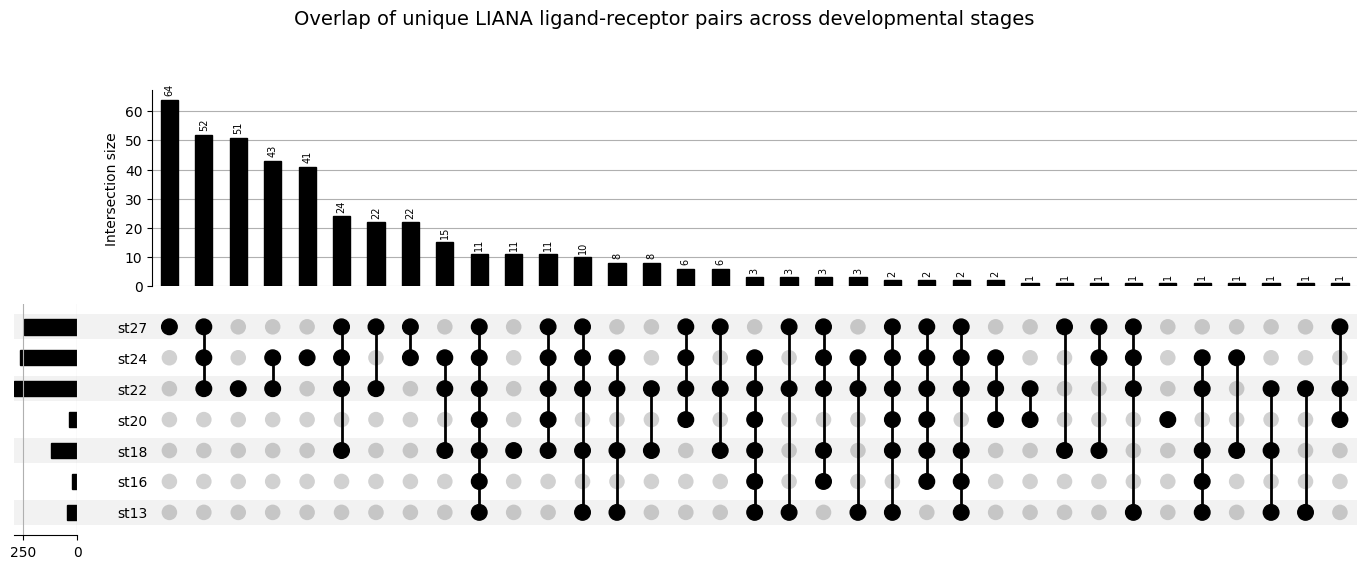

Saved figure: upset_unique_lr_pairs_stagewise.png


In [3]:
# Cell — UpSet plot for UNIQUE ligand-receptor pairs across stages

# -----------------------------
# Load LIANA result files
# -----------------------------
all_rows = []

for stage in stages:
    if stage in manual_files and manual_files[stage].exists():
        file_path = manual_files[stage]
    else:
        stage_dir = parent_output_dir / stage
        possible_files = list(stage_dir.glob("*liana_res*.csv"))

        if len(possible_files) == 0:
            print(f"No LIANA result file found for {stage}")
            continue

        file_path = possible_files[0]

    df = pd.read_csv(file_path)

    required_cols = ["ligand_complex", "receptor_complex"]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"Skipping {stage}; missing columns: {missing_cols}")
        continue

    df = df.copy()
    df["stage"] = stage

    # Unique LR pair identity
    df["lr_pair"] = (
        df["ligand_complex"].astype(str).str.strip() +
        " -> " +
        df["receptor_complex"].astype(str).str.strip()
    )

    all_rows.append(df[["stage", "lr_pair", "ligand_complex", "receptor_complex"]])

combined_df = pd.concat(all_rows, ignore_index=True)

# -----------------------------
# Keep unique LR pair per stage
# -----------------------------
unique_stage_lr = combined_df.drop_duplicates(subset=["stage", "lr_pair"]).copy()

print("Total stage-wise LR rows loaded:", len(combined_df))
print("Unique stage-wise LR pairs:", len(unique_stage_lr))
print("\nUnique LR pairs per stage:")
print(unique_stage_lr.groupby("stage")["lr_pair"].nunique())

# -----------------------------
# Create membership table
# -----------------------------
membership_df = (
    unique_stage_lr
    .groupby("lr_pair")["stage"]
    .apply(lambda x: tuple(sorted(x, key=stages.index)))
    .reset_index(name="membership")
)

membership_df["n_stages"] = membership_df["membership"].apply(len)
membership_df["stages_present"] = membership_df["membership"].apply(lambda x: ", ".join(x))

print("\nTotal unique LR pairs across all stages:")
print(membership_df["lr_pair"].nunique())

# -----------------------------
# Save LR-pair intersection table
# -----------------------------
membership_df.to_csv("upset_unique_lr_pair_stage_membership.csv", index=False)

print("\nSaved table: upset_unique_lr_pair_stage_membership.csv")

# -----------------------------
# Build UpSet input
# -----------------------------
upset_data = from_memberships(
    membership_df["membership"],
    data=pd.Series(1, index=membership_df.index)
)

# -----------------------------
# Plot UpSet with count labels above bars
# -----------------------------
plt.close("all")

fig = plt.figure(figsize=(14, 8))

upset = UpSet(
    upset_data,
    subset_size="count",
    sort_by="cardinality",
    sort_categories_by=None,
    min_subset_size=1,
    show_counts=False
)

axes = upset.plot(fig=fig)

# Get intersection bar axis
bar_ax = axes["intersections"]

# Add count labels above bars safely
for patch in bar_ax.patches:
    height = patch.get_height()

    # skip non-bar patches or zero-height patches
    if not np.isscalar(height) or height <= 0:
        continue

    x = patch.get_x() + patch.get_width() / 2

    # convert safely to normal float
    x = float(np.asarray(x).squeeze())
    height = float(np.asarray(height).squeeze())

    bar_ax.text(
        x,
        height + (0.02 * bar_ax.get_ylim()[1]),
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=90
    )

fig.suptitle(
    "Overlap of unique LIANA ligand-receptor pairs across developmental stages",
    fontsize=14,
    y=1.02
)

fig.savefig("upset_unique_lr_pairs_stagewise.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure: upset_unique_lr_pairs_stagewise.png")

Total LIANA rows loaded: 15360

Rows per stage:
stage
st13     449
st16     250
st18    1620
st20     424
st22    6543
st24    3603
st27    2471
dtype: int64

Unique source-target LR interaction instances per stage:
stage
st13     449
st16     250
st18    1620
st20     424
st22    6543
st24    3603
st27    2471
Name: interaction_instance, dtype: int64

Total unique interaction instances across all stages:
10383

Saved table: upset_liana_source_target_interaction_instance_membership.csv


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["lin

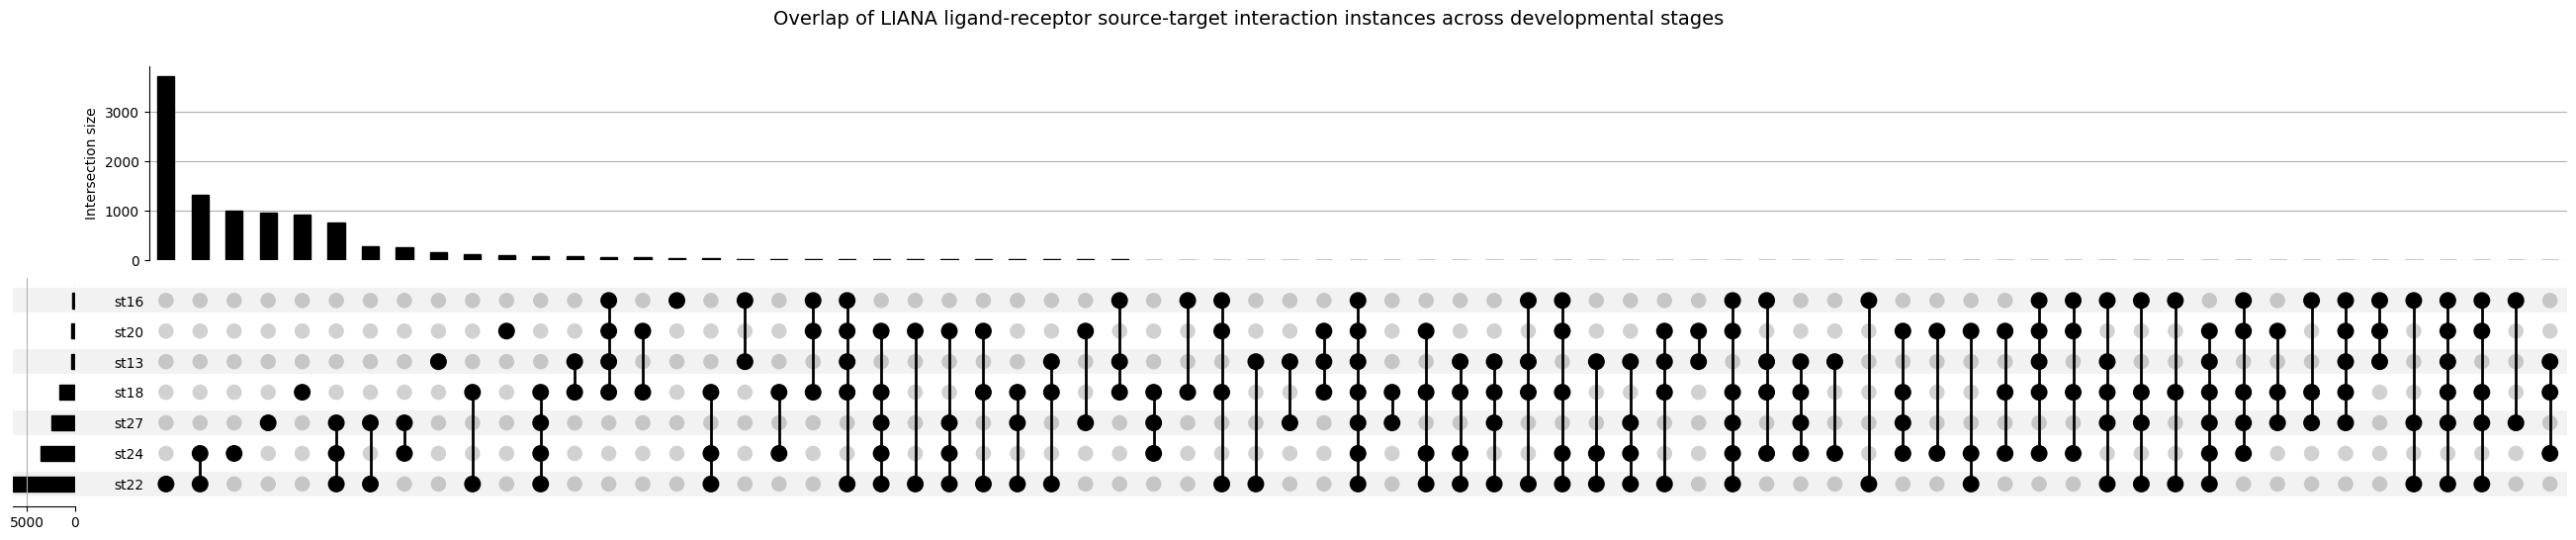

Saved figure: upset_liana_source_target_interaction_instances_stagewise.png


In [4]:
# Cell — UpSet plot WITHOUT unique LR-pair filtering
# This compares LR source-target interaction instances across stages

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships

# -----------------------------
# Settings
# -----------------------------
parent_output_dir = Path("liana_stagewise_results_phenograph")
stages = ["st13", "st16", "st18", "st20", "st22", "st24", "st27"]

manual_files = {
    "st22": Path("st22_liana_res_phenograph.csv")
}

# -----------------------------
# Load LIANA result files
# -----------------------------
all_rows = []

for stage in stages:
    if stage in manual_files and manual_files[stage].exists():
        file_path = manual_files[stage]
    else:
        stage_dir = parent_output_dir / stage
        possible_files = list(stage_dir.glob("*liana_res*.csv"))

        if len(possible_files) == 0:
            print(f"No LIANA result file found for {stage}")
            continue

        file_path = possible_files[0]

    df = pd.read_csv(file_path)

    required_cols = ["ligand_complex", "receptor_complex", "source", "target"]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"Skipping {stage}; missing columns: {missing_cols}")
        continue

    df = df.copy()
    df["stage"] = stage

    df["interaction_instance"] = (
        df["ligand_complex"].astype(str).str.strip() +
        " -> " +
        df["receptor_complex"].astype(str).str.strip() +
        " | " +
        df["source"].astype(str).str.strip() +
        " -> " +
        df["target"].astype(str).str.strip()
    )

    all_rows.append(df[["stage", "interaction_instance", "ligand_complex", "receptor_complex", "source", "target"]])

combined_instance_df = pd.concat(all_rows, ignore_index=True)

print("Total LIANA rows loaded:", len(combined_instance_df))
print("\nRows per stage:")
print(combined_instance_df.groupby("stage").size())

# -----------------------------
# Keep unique interaction instance per stage
# Necessary for UpSet membership logic
# -----------------------------
stage_instance_df = combined_instance_df.drop_duplicates(
    subset=["stage", "interaction_instance"]
).copy()

print("\nUnique source-target LR interaction instances per stage:")
print(stage_instance_df.groupby("stage")["interaction_instance"].nunique())

# -----------------------------
# Create membership table
# -----------------------------
instance_membership_df = (
    stage_instance_df
    .groupby("interaction_instance")["stage"]
    .apply(lambda x: tuple(sorted(x, key=stages.index)))
    .reset_index(name="membership")
)

instance_membership_df["n_stages"] = instance_membership_df["membership"].apply(len)
instance_membership_df["stages_present"] = instance_membership_df["membership"].apply(lambda x: ", ".join(x))

print("\nTotal unique interaction instances across all stages:")
print(instance_membership_df["interaction_instance"].nunique())

# -----------------------------
# Save table
# -----------------------------
instance_membership_df.to_csv(
    "upset_liana_source_target_interaction_instance_membership.csv",
    index=False
)

print("\nSaved table: upset_liana_source_target_interaction_instance_membership.csv")

# -----------------------------
# Build UpSet input
# -----------------------------
upset_instance_data = from_memberships(
    instance_membership_df["membership"],
    data=pd.Series(1, index=instance_membership_df.index)
)

## -----------------------------
# Plot UpSet - source-target interaction instances
# safer version
# -----------------------------
plt.close("all")

fig = plt.figure(figsize=(16, 8))

upset = UpSet(
    upset_instance_data,
    subset_size="count",
    sort_by="cardinality",
    min_subset_size=1,
    show_counts=False
)

upset.plot(fig=fig)

fig.suptitle(
    "Overlap of LIANA ligand-receptor source-target interaction instances across developmental stages",
    fontsize=14,
    y=0.98
)

fig.savefig(
    "upset_liana_source_target_interaction_instances_stagewise.png",
    dpi=300
)

plt.show()

print("Saved figure: upset_liana_source_target_interaction_instances_stagewise.png")

Total selected NOTCH-associated rows loaded:
759

Unique selected NOTCH LR pairs per stage:
stage
st13     4
st16     1
st18     7
st20     2
st22    16
st24    10
st27    17
Name: lr_pair, dtype: int64

Selected NOTCH-associated LR pairs across all stages:
19


,lr_pair,membership,n_stages,stages_present
18,YBX1 -> NOTCH1,"(st13, st16, st18, st22, st24, st27)",6,"st13, st16, st18, st22, st24, st27"
4,DLL1 -> NOTCH1,"(st13, st18, st22, st24, st27)",5,"st13, st18, st22, st24, st27"
6,DLL1 -> NOTCH3,"(st13, st18, st22, st24, st27)",5,"st13, st18, st22, st24, st27"
16,PSEN1 -> NOTCH3,"(st18, st20, st22, st24, st27)",5,"st18, st20, st22, st24, st27"
0,ADAM10 -> NOTCH1,"(st13, st18, st22, st24)",4,"st13, st18, st22, st24"
9,JAG1 -> NOTCH3,"(st20, st22, st24, st27)",4,"st20, st22, st24, st27"
13,MFAP2 -> NOTCH1,"(st18, st22, st24, st27)",4,"st18, st22, st24, st27"
14,PSEN1 -> NOTCH1,"(st18, st22, st24, st27)",4,"st18, st22, st24, st27"
2,ADAM17 -> NOTCH1,"(st22, st24, st27)",3,"st22, st24, st27"
7,JAG1 -> NOTCH1,"(st22, st24, st27)",3,"st22, st24, st27"



Saved table:
selected_notch_lr_pair_stage_membership.csv


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["lin

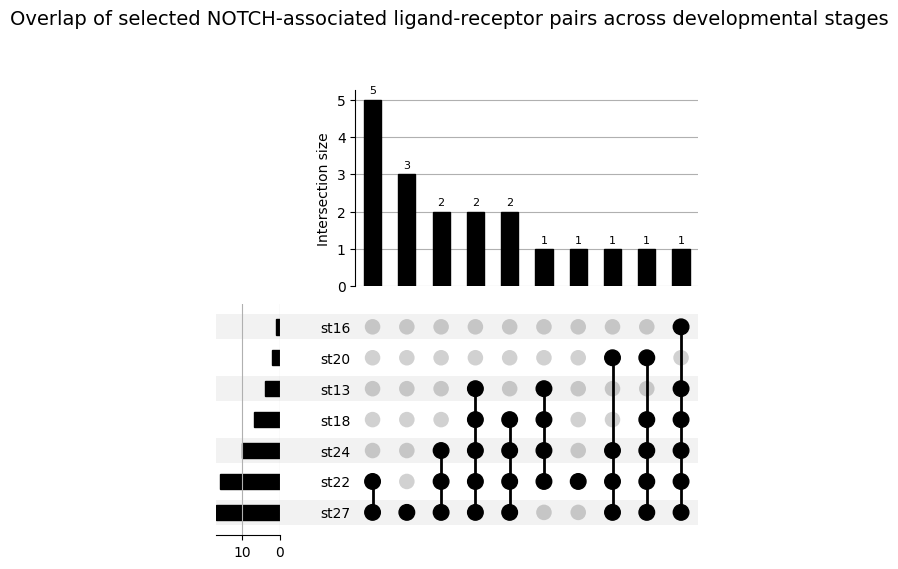


Saved figure:
upset_selected_notch_lr_pairs_stagewise.png


In [1]:
# Cell — UpSet plot for biologically selected NOTCH ligand-receptor pairs across stages

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships
import numpy as np

# -----------------------------
# Settings
# -----------------------------
parent_output_dir = Path("liana_stagewise_results_phenograph")

stages = ["st13", "st16", "st18", "st20", "st22", "st24", "st27"]

manual_files = {
    "st22": Path("st22_liana_res_phenograph.csv")
}

# -----------------------------
# NOTCH-associated LR pairs
# extracted from your dotplots
# -----------------------------
notch_lr_pairs_of_interest = [
    "DLL1 -> NOTCH1",
    "DLL1 -> NOTCH2",
    "DLL1 -> NOTCH3",
    "JAG1 -> NOTCH1",
    "JAG1 -> NOTCH2",
    "JAG1 -> NOTCH3",
    "PSEN1 -> NOTCH1",
    "PSEN1 -> NOTCH2",
    "PSEN1 -> NOTCH3",
    "ADAM10 -> NOTCH1",
    "ADAM10 -> NOTCH2",
    "ADAM17 -> NOTCH1",
    "MFAP2 -> NOTCH1",
    "MDK -> NOTCH2",
    "APP -> NOTCH2",
    "YBX1 -> NOTCH1",
    "JAG2 -> NOTCH1",
    "JAG2 -> NOTCH3",
    "WNT4 -> NOTCH1"
]

# uppercase for safe matching
notch_lr_pairs_of_interest = [x.upper() for x in notch_lr_pairs_of_interest]

# -----------------------------
# Load LIANA results
# -----------------------------
all_rows = []

for stage in stages:

    if stage in manual_files and manual_files[stage].exists():
        file_path = manual_files[stage]
    else:
        stage_dir = parent_output_dir / stage
        possible_files = list(stage_dir.glob("*liana_res*.csv"))

        if len(possible_files) == 0:
            print(f"No LIANA result file found for {stage}")
            continue

        file_path = possible_files[0]

    df = pd.read_csv(file_path)

    required_cols = ["ligand_complex", "receptor_complex"]

    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"Skipping {stage}; missing columns: {missing_cols}")
        continue

    df = df.copy()

    df["ligand_complex"] = (
        df["ligand_complex"]
        .astype(str)
        .str.strip()
    )

    df["receptor_complex"] = (
        df["receptor_complex"]
        .astype(str)
        .str.strip()
    )

    df["lr_pair"] = (
        df["ligand_complex"] +
        " -> " +
        df["receptor_complex"]
    )

    df["lr_pair_upper"] = df["lr_pair"].str.upper()

    # Keep only selected NOTCH-associated LR pairs
    df = df[
        df["lr_pair_upper"].isin(notch_lr_pairs_of_interest)
    ].copy()

    df["stage"] = stage

    all_rows.append(
        df[["stage", "lr_pair"]]
    )

# -----------------------------
# Combine all stages
# -----------------------------
combined_df = pd.concat(all_rows, ignore_index=True)

print("Total selected NOTCH-associated rows loaded:")
print(len(combined_df))

# -----------------------------
# Keep unique LR pair per stage
# -----------------------------
unique_stage_lr = combined_df.drop_duplicates(
    subset=["stage", "lr_pair"]
).copy()

print("\nUnique selected NOTCH LR pairs per stage:")
print(
    unique_stage_lr.groupby("stage")["lr_pair"].nunique()
)

# -----------------------------
# Create membership table
# -----------------------------
membership_df = (
    unique_stage_lr
    .groupby("lr_pair")["stage"]
    .apply(lambda x: tuple(sorted(x, key=stages.index)))
    .reset_index(name="membership")
)

membership_df["n_stages"] = (
    membership_df["membership"].apply(len)
)

membership_df["stages_present"] = (
    membership_df["membership"]
    .apply(lambda x: ", ".join(x))
)

print("\nSelected NOTCH-associated LR pairs across all stages:")
print(membership_df["lr_pair"].nunique())

display(
    membership_df.sort_values(
        ["n_stages", "lr_pair"],
        ascending=[False, True]
    )
)

# -----------------------------
# Save membership table
# -----------------------------
membership_df.to_csv(
    "selected_notch_lr_pair_stage_membership.csv",
    index=False
)

print("\nSaved table:")
print("selected_notch_lr_pair_stage_membership.csv")

# -----------------------------
# Build UpSet input
# -----------------------------
upset_data = from_memberships(
    membership_df["membership"],
    data=pd.Series(1, index=membership_df.index)
)

# -----------------------------
# Plot UpSet
# -----------------------------
plt.close("all")

fig = plt.figure(figsize=(12, 7))

upset = UpSet(
    upset_data,
    subset_size="count",
    sort_by="cardinality",
    min_subset_size=1,
    show_counts=False
)

axes = upset.plot(fig=fig)

# -----------------------------
# Add count labels
# -----------------------------
bar_ax = axes["intersections"]

for patch in bar_ax.patches:

    height = patch.get_height()

    if not np.isscalar(height) or height <= 0:
        continue

    x = patch.get_x() + patch.get_width() / 2

    x = float(np.asarray(x).squeeze())
    height = float(np.asarray(height).squeeze())

    bar_ax.text(
        x,
        height + 0.1,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0
    )

# -----------------------------
# Title + save
# -----------------------------
fig.suptitle(
    "Overlap of selected NOTCH-associated ligand-receptor pairs across developmental stages",
    fontsize=14,
    y=1.02
)

fig.savefig(
    "upset_selected_notch_lr_pairs_stagewise.png",
    dpi=300
)

plt.show()

print("\nSaved figure:")
print("upset_selected_notch_lr_pairs_stagewise.png")

/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are settin

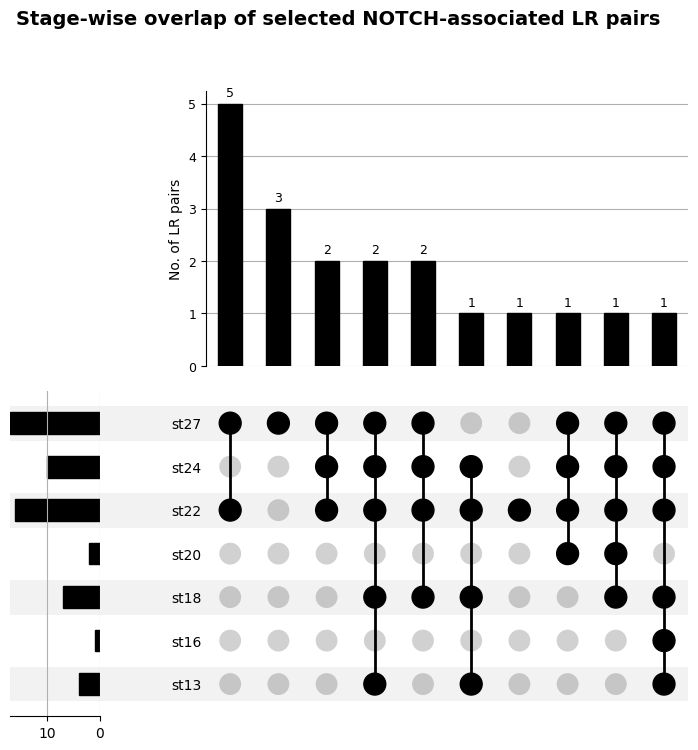

Saved figure: upset_selected_notch_lr_pairs_stagewise_improved.png


In [2]:
# -----------------------------
# Plot improved UpSet
# -----------------------------
plt.close("all")

fig = plt.figure(figsize=(10, 6))

upset = UpSet(
    upset_data,
    subset_size="count",
    sort_by="cardinality",
    sort_categories_by=None,
    min_subset_size=1,
    show_counts=False,
    element_size=45,
    intersection_plot_elements=6,
    totals_plot_elements=2
)

axes = upset.plot(fig=fig)

# Improve intersection bar labels
bar_ax = axes["intersections"]

for patch in bar_ax.patches:
    height = patch.get_height()

    if not np.isscalar(height) or height <= 0:
        continue

    x = float(np.asarray(patch.get_x() + patch.get_width() / 2).squeeze())
    height = float(np.asarray(height).squeeze())

    bar_ax.text(
        x,
        height + 0.08,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

bar_ax.set_ylabel("No. of LR pairs", fontsize=10)
bar_ax.tick_params(axis="both", labelsize=9)

# Clean title
fig.suptitle(
    "Stage-wise overlap of selected NOTCH-associated LR pairs",
    fontsize=14,
    fontweight="bold",
    y=0.98
)

fig.savefig(
    "upset_selected_notch_lr_pairs_stagewise_improved.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure: upset_selected_notch_lr_pairs_stagewise_improved.png")

,Stage,Total_LR_interactions,Unique_LR_pairs
0,st13,449,46
1,st16,250,22
2,st18,1620,121
3,st20,424,40
4,st22,6543,293
5,st24,3603,264
6,st27,2471,244


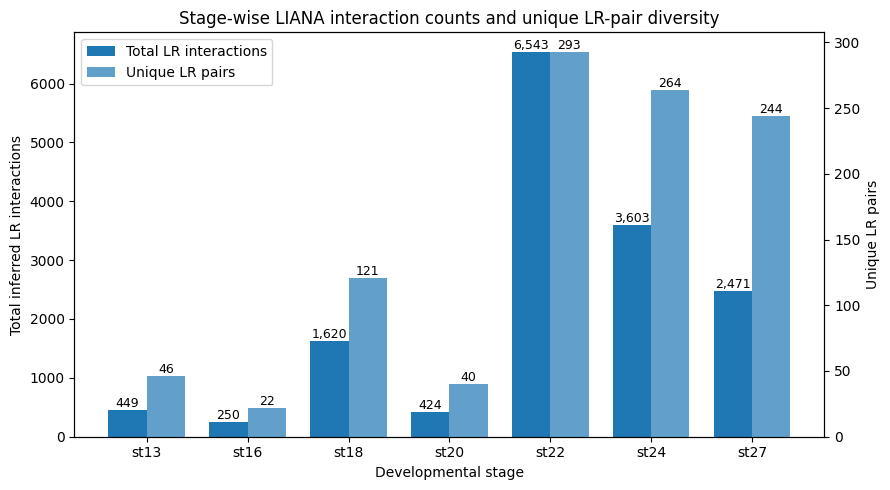

In [4]:
# ============================================================
# 3.3.1 Overview of inferred ligand–receptor interactions
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# -----------------------------
# Create output folder
# -----------------------------
output_dir = Path("results_section_figures")
output_dir.mkdir(exist_ok=True)

# -----------------------------
# Input: stage-wise LIANA counts
# -----------------------------
lr_counts = pd.DataFrame({
    "Stage": ["st13", "st16", "st18", "st20", "st22", "st24", "st27"],
    "Total_LR_interactions": [449, 250, 1620, 424, 6543, 3603, 2471],
    "Unique_LR_pairs": [46, 22, 121, 40, 293, 264, 244]
})

# Add developmental order
stage_order = ["st13", "st16", "st18", "st20", "st22", "st24", "st27"]
lr_counts["Stage"] = pd.Categorical(lr_counts["Stage"], categories=stage_order, ordered=True)
lr_counts = lr_counts.sort_values("Stage")

# Display and save table
display(lr_counts)
lr_counts.to_csv(output_dir / "stagewise_liana_lr_interaction_and_unique_pair_counts.csv", index=False)

# -----------------------------
# Grouped bar plot
# -----------------------------
x = np.arange(len(lr_counts))
width = 0.38

fig, ax1 = plt.subplots(figsize=(9, 5))

bars1 = ax1.bar(
    x - width/2,
    lr_counts["Total_LR_interactions"],
    width,
    label="Total LR interactions"
)

ax1.set_xlabel("Developmental stage")
ax1.set_ylabel("Total inferred LR interactions")
ax1.set_xticks(x)
ax1.set_xticklabels(lr_counts["Stage"].astype(str))

# Second y-axis for unique LR pairs
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    lr_counts["Unique_LR_pairs"],
    width,
    label="Unique LR pairs",
    alpha=0.7
)

ax2.set_ylabel("Unique LR pairs")

# -----------------------------
# Add labels
# -----------------------------
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# -----------------------------
# Title and legend
# -----------------------------
ax1.set_title("Stage-wise LIANA interaction counts and unique LR-pair diversity")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

fig.tight_layout()

# -----------------------------
# Save figure
# -----------------------------
fig.savefig(
    output_dir / "stagewise_liana_interactions_and_unique_lr_pairs_grouped_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    output_dir / "stagewise_liana_interactions_and_unique_lr_pairs_grouped_barplot.pdf",
    bbox_inches="tight"
)

plt.show()

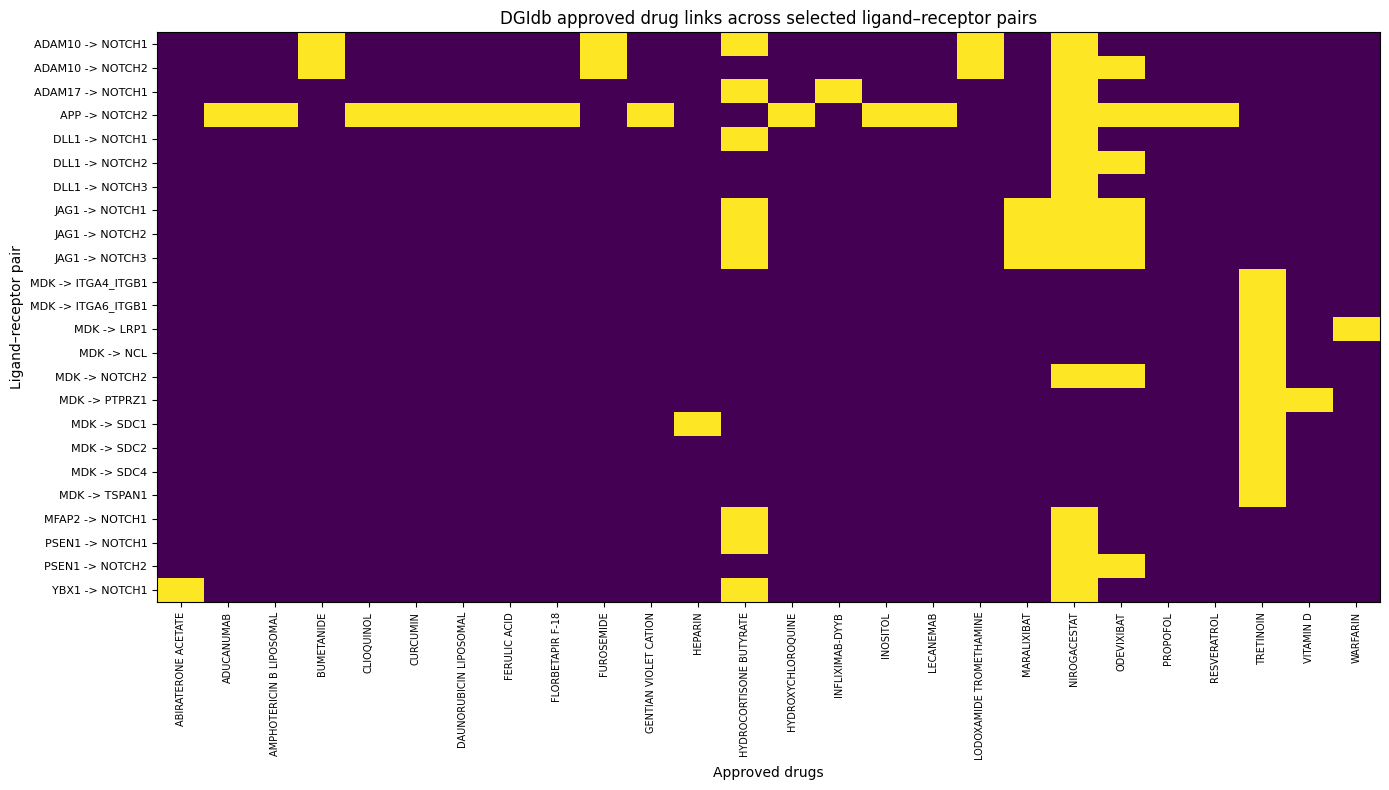

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

heatmap_df = (
    drug_links
    .drop_duplicates(subset=["lr_pair", "drug_name"])
    .assign(linked=1)
    .pivot_table(
        index="lr_pair",
        columns="drug_name",
        values="linked",
        fill_value=0
    )
)

plt.figure(figsize=(14, 8))
plt.imshow(heatmap_df, aspect="auto")

plt.xticks(
    range(len(heatmap_df.columns)),
    heatmap_df.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(heatmap_df.index)),
    heatmap_df.index,
    fontsize=8
)

plt.xlabel("Approved drugs")
plt.ylabel("Ligand–receptor pair")
plt.title("DGIdb approved drug links across selected ligand–receptor pairs")

plt.tight_layout()
plt.savefig("dgidb_lr_pair_drug_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

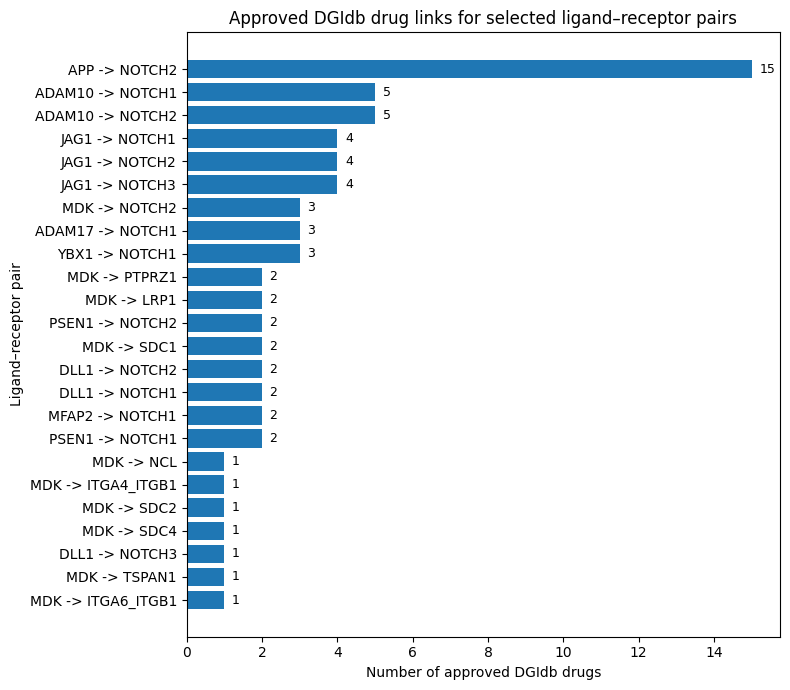

,lr_pair,drug_linked_genes,n_approved_drugs,example_approved_drugs
3,APP -> NOTCH2,APP; NOTCH2,15,ADUCANUMAB; AMPHOTERICIN B LIPOSOMAL; CLIOQUIN...
0,ADAM10 -> NOTCH1,ADAM10; NOTCH1,5,BUMETANIDE; FUROSEMIDE; HYDROCORTISONE BUTYRAT...
1,ADAM10 -> NOTCH2,ADAM10; NOTCH2,5,BUMETANIDE; FUROSEMIDE; LODOXAMIDE TROMETHAMIN...
7,JAG1 -> NOTCH1,JAG1; NOTCH1,4,HYDROCORTISONE BUTYRATE; MARALIXIBAT; NIROGACE...
9,JAG1 -> NOTCH3,JAG1; NOTCH3,4,HYDROCORTISONE BUTYRATE; MARALIXIBAT; NIROGACE...
8,JAG1 -> NOTCH2,JAG1; NOTCH2,4,HYDROCORTISONE BUTYRATE; MARALIXIBAT; NIROGACE...
14,MDK -> NOTCH2,MDK; NOTCH2,3,NIROGACESTAT; ODEVIXIBAT; TRETINOIN
23,YBX1 -> NOTCH1,NOTCH1; YBX1,3,ABIRATERONE ACETATE; HYDROCORTISONE BUTYRATE; ...
2,ADAM17 -> NOTCH1,ADAM17; NOTCH1,3,HYDROCORTISONE BUTYRATE; INFLIXIMAB-DYYB; NIRO...
5,DLL1 -> NOTCH2,NOTCH2,2,NIROGACESTAT; ODEVIXIBAT


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Create summary table from drug_links
# -----------------------------
drug_summary = (
    drug_links[["lr_pair", "gene_name", "drug_name"]]
    .dropna()
    .drop_duplicates()
    .groupby("lr_pair")
    .agg(
        drug_linked_genes=("gene_name", lambda x: "; ".join(sorted(set(x)))),
        n_approved_drugs=("drug_name", lambda x: len(set(x))),
        example_approved_drugs=("drug_name", lambda x: "; ".join(sorted(set(x))[:5]))
    )
    .reset_index()
)

# -----------------------------
# Plot
# -----------------------------
plot_df = drug_summary.sort_values("n_approved_drugs", ascending=True)

plt.figure(figsize=(8, 7))

bars = plt.barh(
    plot_df["lr_pair"],
    plot_df["n_approved_drugs"]
)

plt.xlabel("Number of approved DGIdb drugs")
plt.ylabel("Ligand–receptor pair")
plt.title("Approved DGIdb drug links for selected ligand–receptor pairs")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("dgidb_approved_drugs_per_lr_pair_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

display(drug_summary.sort_values("n_approved_drugs", ascending=False))